In [83]:
# Import necessary libraries
import os
import glob
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [103]:
# User Input Parameters (CHANGE)
date_str = "20260204"  # YYYYMMDD format
start_time = "000000"  # HHMMSS format
end_time = "160000"  # HHMMSS format

# Optional: Set end_time_mask to limit x-axis display (set to None to disable)
end_time_mask = "145200"  # HHMMSS format - cuts off display at this time

# Base path for acoustic data
base_path = "/Users/xylu/Desktop/Data/acoustic_vpp/"

# Convert strings to datetime objects for filtering
date_obj = datetime.strptime(date_str, "%Y%m%d")
start_time_obj = datetime.strptime(date_str + start_time_str, "%Y%m%d%H%M%S")
end_time_obj = datetime.strptime(date_str + end_time_str, "%Y%m%d%H%M%S")

# Convert mask time if provided
if end_time_mask is not None:
    end_time_mask_obj = datetime.strptime(date_str + end_time_mask, "%Y%m%d%H%M%S")
else:
    end_time_mask_obj = None

print(f"Date: {date_str}")
print(f"Time range: {start_time} - {end_time}")
print(f"Start: {start_time_obj.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"End: {end_time_obj.strftime('%Y-%m-%d %H:%M:%S')}")
if end_time_mask_obj:
    print(f"Display mask: {end_time_mask_obj.strftime('%Y-%m-%d %H:%M:%S')}")

Date: 20260204
Time range: 000000 - 160000
Start: 2026-02-04 00:00:00
End: 2026-02-04 16:00:00
Display mask: 2026-02-04 14:52:00


In [104]:
# Load CSV files for the specified date
print("\n" + "="*60)
print("Looking for CSV files...")
print("="*60)

# Direct path: files are stored in /acoustic_vpp/YYYYMMDD/
date_folder = os.path.join(base_path, date_str)

if not os.path.exists(date_folder):
    print(f"⚠ Folder not found: {date_folder}")
    filtered_df = None
else:
    print(f"✓ Found folder: {date_folder}")
    
    # Find all CSV files matching the date pattern
    csv_files = sorted(glob.glob(os.path.join(date_folder, f"{date_str}*.csv")))
    print(f"  Found {len(csv_files)} CSV file(s)")
    
    if len(csv_files) == 0:
        print(f"⚠ No CSV files found matching {date_str}*.csv")
        filtered_df = None
    else:
        # Load and combine all CSV files
        all_data = []
        
        for csv_file in csv_files:
            try:
                df = pd.read_csv(csv_file)
                # Convert time_datetime to datetime if it's a string (handles microseconds)
                if 'time_datetime' in df.columns:
                    df['time_datetime'] = pd.to_datetime(df['time_datetime'], format='ISO8601')
                all_data.append(df)
                print(f"  ✓ {os.path.basename(csv_file)}: {len(df)} samples")
            except Exception as e:
                print(f"  ✗ Error reading {os.path.basename(csv_file)}: {e}")
        
        if all_data:
            # Combine all data
            combined_df = pd.concat(all_data, ignore_index=True)
            combined_df = combined_df.sort_values('time_datetime').reset_index(drop=True)
            
            print(f"\n✓ Combined data: {len(combined_df)} total samples")
            print(f"  Time range: {combined_df['time_datetime'].min()} to {combined_df['time_datetime'].max()}")
            
            # Filter by time range
            mask = (combined_df['time_datetime'] >= start_time_obj) & (combined_df['time_datetime'] <= end_time_obj)
            filtered_df = combined_df[mask].reset_index(drop=True)
            
            print(f"\n✓ Filtered data (between {start_time_obj.strftime('%H:%M:%S')} and {end_time_obj.strftime('%H:%M:%S')}): {len(filtered_df)} samples")
            
            if len(filtered_df) > 0:
                print(f"  Vpp range: {filtered_df['vpp_volts'].min():.4f} - {filtered_df['vpp_volts'].max():.4f} V")
            else:
                print("  ⚠ No data after filtering by time range")
        else:
            print("⚠ No data loaded!")
            filtered_df = None


Looking for CSV files...
✓ Found folder: /Users/xylu/Desktop/Data/acoustic_vpp/20260204
  Found 288 CSV file(s)
  ✓ 20260204_000000_n_vpp.csv: 6000 samples
  ✓ 20260204_000500_n_vpp.csv: 6000 samples
  ✓ 20260204_001000_n_vpp.csv: 6000 samples
  ✓ 20260204_001500_n_vpp.csv: 6000 samples
  ✓ 20260204_002000_n_vpp.csv: 6000 samples
  ✓ 20260204_002500_n_vpp.csv: 6000 samples
  ✓ 20260204_003000_n_vpp.csv: 6020 samples
  ✓ 20260204_003500_n_vpp.csv: 6000 samples
  ✓ 20260204_004000_n_vpp.csv: 6000 samples
  ✓ 20260204_004500_n_vpp.csv: 5999 samples
  ✓ 20260204_005000_n_vpp.csv: 6000 samples
  ✓ 20260204_005500_n_vpp.csv: 6000 samples
  ✓ 20260204_010000_n_vpp.csv: 6000 samples
  ✓ 20260204_010500_n_vpp.csv: 6000 samples
  ✓ 20260204_011000_n_vpp.csv: 6000 samples
  ✓ 20260204_011500_n_vpp.csv: 6000 samples
  ✓ 20260204_012000_n_vpp.csv: 6000 samples
  ✓ 20260204_012500_n_vpp.csv: 6000 samples
  ✓ 20260204_013000_n_vpp.csv: 6020 samples
  ✓ 20260204_013500_n_vpp.csv: 6000 samples
  ✓ 202

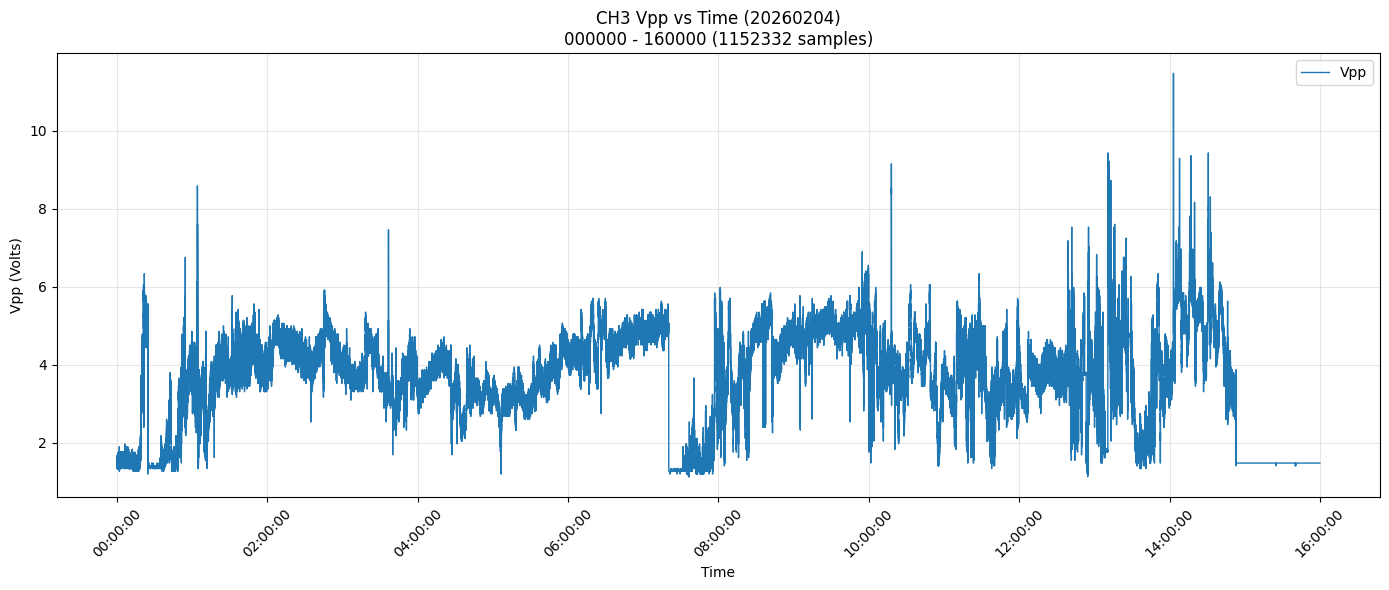


Data Statistics
Min Vpp: 1.1261 V
Max Vpp: 11.4719 V
Mean Vpp: 3.6075 V
Median Vpp: 3.7301 V
Std Dev: 1.2100 V
Total samples: 1152332
Duration: 57600.0 seconds


In [ ]:
# Plot Vpp vs Time
if filtered_df is not None and len(filtered_df) > 0:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    ax.plot(filtered_df['time_datetime'], filtered_df['vpp_volts'], linewidth=1, label='Vpp')
    ax.set_xlabel("Time")
    ax.set_ylabel("Vpp (Volts)")
    ax.set_title(f"CH3 Vpp vs Time ({date_str})\n{start_time_str} - {end_time_str} ({len(filtered_df)} samples)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Format x-axis
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    ax.tick_params(axis='both', labelsize=12)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\n" + "="*60)
    print("Data Statistics")
    print("="*60)
    print(f"Min Vpp: {filtered_df['vpp_volts'].min():.4f} V")
    print(f"Max Vpp: {filtered_df['vpp_volts'].max():.4f} V")
    print(f"Mean Vpp: {filtered_df['vpp_volts'].mean():.4f} V")
    print(f"Median Vpp: {filtered_df['vpp_volts'].median():.4f} V")
    print(f"Std Dev: {filtered_df['vpp_volts'].std():.4f} V")
    print(f"Total samples: {len(filtered_df)}")
    print(f"Duration: {(filtered_df['time_datetime'].max() - filtered_df['time_datetime'].min()).total_seconds()} seconds")
else:
    print("No data to plot!")

In [106]:
# Define friendly name mapping (from multi_plot_add_acoustic.ipynb)
pv_mapping = [
    # --- Vacuum Pressure Sensors ---
    ("VALCCG:D01_L01A:PRES", "VAC_D01L01A"),
    ("VALCCG:D01_L02:PRES", "VAC_D01L02"),
    ("VALCCG:D01_L03:PRES", "VAC_D01L03"),
    ("VALCCG:D01_L04:PRES", "VAC_D01L04"),
    ("VALCCG:D04_L01:PRES", "VAC_D4L01"),
    ("VALCCG:D04_L02:PRES", "VAC_D4L02"),
    ("VALCCG:D04_L03:PRES", "VAC_D4L03"),
    ("VALCCG:D04_L04:PRES", "VAC_D4L04"),
    ("VALCCG:D04_L05:PRES", "VAC_D4L05"),
    ("VALCCG:D04_L06:PRES", "VAC_D4L06"),
    ("VALCCG:D04_L07:PRES", "VAC_D4L07"),
    ("VALCCG:D04_L08:PRES", "VAC_D4L08"),
    ("VALCCG:D04_L09:PRES", "VAC_D04L09"),
    ("VALCCG:D05_L18:PRES", "VAC_D05L18"),
    ("VALCCG:D05_L20:PRES", "VAC_D05L20"),
    ("VALCCG:D05_L21:PRES", "VAC_D05L21"),
    ("VALCCG:D05_L22:PRES", "VAC_D05L22"),
    ("VALCCG:D05_L22A:PRES", "VAC_D05L22A"),
    ("VALCCG:D05_L23:PRES", "VAC_D05L23"),
    ("VALCCG:D05_L24:PRES", "VAC_D05L24"),
    ("VALCCG:D05_L25:PRES", "VAC_D05L25"),
    ("VALCCG:D05_L26:PRES", "VAC_D05L26"),
    ("VALCCG:D07_L0:PRES", "VAC_D07L0"),
    ("VALCCG:D07_L00:PRES", "VAC_D07L00"),
    ("VALCCG:D07_L01:PRES", "VAC_D07L01"),
    ("VALCCG:D07_L02:PRES", "VAC_D07L02"),
    ("VALCCG:D07_L03:PRES", "VAC_D07L03"),
    ("VALCCG:D07_L04:PRES", "VAC_D07L04"),
    ("VALCCG:D07_L05:PRES", "VAC_D07L05"),
    ("VALCCG:D07_L05A:PRES", "VAC_D07L05A"),
    ("VALCCG:D07_L06:PRES", "VAC_D07L06"),
    ("VALCCG:D07_L07:PRES", "VAC_D07L07"),
    ("VALCCG:D07_L08:PRES", "VAC_D07L08"),
    ("VALCCG:D07_L09:PRES", "VAC_D07L09"),
    ("VALCCG:D07_L10:PRES", "VAC_D07L10"),
    ("VALCCG:D07_L11:PRES", "VAC_D07L11"),
    ("VALCCG:D10_L01:PRES", "VAC_D10L01"),
    ("VALCCG:D10_L02:PRES", "VAC_D10L02"),
    ("VALCCG:D10_L03:PRES", "VAC_D10L03"),
    ("VALCCG:D10_L04:PRES", "VAC_D10L04"),
    ("VALCCG:D10_L05:PRES", "VAC_D10L05"),
    ("VALCCG:D10_L06:PRES", "VAC_D10L06"),
    ("VALCCG:D10_L07:PRES", "VAC_D10L07"),
    ("VALCCG:D10_L08:PRES", "VAC_D10L08"),
    ("VALCCG:D11_L18:PRES", "VAC_D11L18"),
    ("VALCCG:D11_L19:PRES", "VAC_D11L19"),
    ("VALCCG:D11_L20:PRES", "VAC_D11L20"),
    ("VALCCG:D11_L21:PRES", "VAC_D11L21"),
    ("VALCCG:D11_L22:PRES", "VAC_D11L22"),
    ("VALCCG:D11_L23:PRES", "VAC_D11L23"),
    ("VALCCG:D11_L24:PRES", "VAC_D11L24"),

    # --- Radiation and Detectors ---
    ("B2_VXD:Rad:Res:BPATDCU3:A1:DoseRate", "B_DMD_DoseRate"),
    ("B2_VXD:Rad:QCS_FW_225:DoseRate", "B_DMD_QCS_FW_225"),
    ("B2_VXD:Rad:QCS_FW_135:DoseRate", "B_DMD_QCS_FW_135"),
    ("B2_CDC:CUR:LOGGER:L15_2:MAX", "B_CDC_Imax_uA"),
    ("B2_CDC:CUR_AVERAGE", "B_CDC_Iavg_uA"),
    ("B2_TOP:TYPE2_avg_scalerRate_PMT17-32", "B_PMThits_Hz"),
    ("B2_TOP:TYPE2_avg_scalerRate_PMT17-32_60", "B_PMThits_avg60s"),
    ("B2_nsm:get:TRGOSCILLO0:lff_ler", "B_ECL_BG_duration_ms"),
    ("B2_nsm:get:ECLTRG_FAM:rate_bw", "B_ECL_BW"),

    # --- Beam Parameters and Injection ---
    ("B2_nsm:get:ECL_LUM_MON:lum_acc_20", "A_LUMI_30"),
    ("CG_OPR:SpecificLuminosity", "A_LUMI_SP_30"),
    ("BMLDCCT:CURRENT", "A_BM_Current_mA"),
    ("BMLDCCT:RATE", "A_BM_Inj_Rate_mAps"),
    ("BMLDCCT:LIFE", "A_BM_Lifetime_min"),
    ("CGLOPT:IP:BETA_Y", "A_BM_BetaY_IP_m"),
    ("CGLOPT:IP:BETA_X", "A_BM_BetaX_IP_m"),
    ("BMLXRM:BEAM:SIGMAX", "A_BM_SigmaX_IP_um"),
    ("BMLXRM:BEAM:SIGMAY", "A_BM_SigmaY_IP_um"),
    ("CG_OPT:CAP:SIGMAY", "A_BM_CapSigmaY_um"),
    ("BTpBPM:QMD11P_K_1:NC_1Hz:C", "A_Qep_BT_end_nC"),
    ("LIiBM:SP_61_8_1:ISNGL:KBP", "A_Qep_Linac_end_nC"),
    ("CGLINJ:EFFICIENCY", "A_INJ_Effi"),
    ("LIiEV:BEAM_REP:READ:KBP", "A_INJ_Rep_ep_Hz"),
    ("CGLINJ:KICKER:HEIGHT_R", "A_INJ_Kicker_Height_mm"),
    ("CGLINJ:KICKER:JUMP_R", "A_INJ_Kicker_Jump"),
    ("CGLINJ:SEPTUM:POS_R", "A_INJ_Septum_Pos_mm"),
    ("CGLINJ:SEPTUM:ANG_R", "A_INJ_Septum_Ang_mm"),
    ("LIiRF:MOPS:SET_PHASE:LER", "A_INJ_Phase"),
    ("CGLINJ:INJECTION:YPOS", "A_INJ_PosY_m"),
    ("CGLINJ:INJECTION:YANG", "A_INJ_AngY_rad"),
    ("BMLD07:INJ:X", "A_INJ_D7_BPMX_mm"),
    ("BMLD07:INJ:Y", "A_INJ_D7_BPMY_mm"),
    ("BMLD07:INJ:Q", "A_INJ_D7_Charge"),
    ("VALCLM:D06CV1TOP:RQ:SET_POS", "A_D6V1_TOP_Head_Pos_Set"),
    ("VALCLM:D06CV1TOP:ST:POS", "A_D6V1_TOP_Head_Pos_Meas"),
    ("VALCLM:D06CV1BTM:RQ:SET_POS", "A_D6V1_BTM_Head_Pos_Set"),
    ("VALCLM:D06CV1BTM:ST:POS", "A_D6V1_BTM_Head_Pos_Meas"),
    ("BML:MQTAFOP1:POS.PXP", "A_D6V1_Upstrm_BPM_PosX"),
    ("BML:MQTAFOP1:POS.PYP", "A_D6V1_Upstrm_BPM_PosY"),
    ("BML:MQT3FOP1:POS.PXP", "A_D6V1_Downstrm_BPM_PosX"),
    ("BML:MQT3FOP1:POS.PYP", "A_D6V1_Downstrm_BPM_PosY"),
    ("BM_BLM:BTCBT:ADC:MEAN", "A_INJ_Loss_Monitor"),

    # --- Acoustic Sensors ---
    ("RFLAE:D06:OSC1:CH1:MIN", "ACOU_Top_Min"),
    ("RFLAE:D06:OSC1:CH1:MAX", "ACOU_Top_Max"),
    ("RFLAE:D06:OSC1:CH1:VPP", "ACOU_Top_Vpp"),
    ("RFLAE:D06:OSC1:CH2:MIN", "ACOU_BmLoss_Min"),
    ("RFLAE:D06:OSC1:CH2:MAX", "ACOU_BmLoss_Max"),
    ("RFLAE:D06:OSC1:CH2:VPP", "ACOU_BmLoss_Vpp"),
    ("RFLAE:D06:OSC1:CH3:MIN", "ACOU_Btm_Min"),
    ("RFLAE:D06:OSC1:CH3:MAX", "ACOU_Btm_Max"),
    ("RFLAE:D06:OSC1:CH3:VPP", "ACOU_Btm_Vpp")
]

# Create mapping dictionary for fast lookup
pv_dict = {k: v for k, v in pv_mapping}

# Function to get friendly name or return original column name if not found
def get_friendly_name(col_name):
    return pv_dict.get(col_name, col_name)

print(f"Loaded {len(pv_mapping)} PV name mappings")

Loaded 102 PV name mappings


In [107]:
# Load machine data from Machine subfolder
machine_folder = os.path.join(base_path, date_str, "Machine")

if not os.path.exists(machine_folder):
    print(f"⚠ Machine folder not found: {machine_folder}")
    machine_df = None
else:
    print(f"✓ Found Machine folder: {machine_folder}")
    
    # Find CSV files in Machine folder
    machine_csv_files = sorted(glob.glob(os.path.join(machine_folder, "*.csv")))
    
    if len(machine_csv_files) == 0:
        print(f"  ⚠ No CSV files found in Machine folder")
        machine_df = None
    else:
        print(f"  Found {len(machine_csv_files)} machine data file(s)")
        
        # Load and combine all machine data files
        machine_data_list = []
        
        for csv_file in machine_csv_files:
            try:
                df_temp = pd.read_csv(csv_file)
                # Convert Timestamp to datetime
                if 'Timestamp' in df_temp.columns:
                    df_temp['Timestamp'] = pd.to_datetime(df_temp['Timestamp'], format='ISO8601')
                machine_data_list.append(df_temp)
                print(f"  ✓ {os.path.basename(csv_file)}: {len(df_temp)} samples, {len(df_temp.columns)} columns")
            except Exception as e:
                print(f"  ✗ Error reading {os.path.basename(csv_file)}: {e}")
        
        if machine_data_list:
            # Combine all machine data
            machine_df = pd.concat(machine_data_list, ignore_index=True)
            machine_df = machine_df.sort_values('Timestamp').reset_index(drop=True)
            
            # Rename Timestamp to time_datetime for consistency
            machine_df.rename(columns={'Timestamp': 'time_datetime'}, inplace=True)
            
            # Rename columns to friendly names
            machine_df.rename(columns=get_friendly_name, inplace=True)
            
            print(f"\n✓ Combined machine data: {len(machine_df)} samples")
            print(f"  Time range: {machine_df['time_datetime'].min()} to {machine_df['time_datetime'].max()}")
            print(f"  Columns ({len(machine_df.columns)}): {list(machine_df.columns[:10])}...")
            
            # Filter by time range
            mask = (machine_df['time_datetime'] >= start_time_obj) & (machine_df['time_datetime'] <= end_time_obj)
            machine_df_filtered = machine_df[mask].reset_index(drop=True)
            
            print(f"\n✓ Filtered machine data: {len(machine_df_filtered)} samples")
        else:
            print("⚠ No machine data loaded!")
            machine_df = None
            machine_df_filtered = None

✓ Found Machine folder: /Users/xylu/Desktop/Data/acoustic_vpp/20260204/Machine
  Found 1 machine data file(s)
  ✓ 2026-03-02T12_54_00.231Z.csv: 31766 samples, 21 columns

✓ Combined machine data: 31766 samples
  Time range: 2026-01-31 15:11:04.380000 to 2026-02-04 16:00:00
  Columns (21): ['time_datetime', 'A_LUMI_30', 'A_LUMI_SP_30', 'A_BM_Current_mA', 'A_BM_BetaY_IP_m', 'A_BM_BetaX_IP_m', 'A_BM_CapSigmaY_um', 'A_Qep_BT_end_nC', 'A_INJ_Effi', 'A_INJ_Rep_ep_Hz']...

✓ Filtered machine data: 31750 samples


In [108]:
# Select variables to plot (CHANGE THIS LIST)
# Available columns can be seen from the machine_df_filtered dataframe
# Use friendly names from the pv_mapping

variables_to_plot = [
    "A_LUMI_30",
    # "A_LUMI_SP_30",
    "A_BM_Current_mA",
    # "A_BM_BetaY_IP_m",
    # "A_BM_BetaX_IP_m",
    # "A_BM_CapSigmaY_um",
    # "A_Qep_BT_end_nC",
    # "A_Qep_Linac_end_nC (?)",
    "A_INJ_Effi",
    # "A_INJ_Rep_ep_Hz",
    # "A_INJ_Kicker_Height_mm",
    # "A_INJ_Kicker_Jump",
    # "A_INJ_Septum_Pos_mm",
    # "A_INJ_Septum_Ang_mm",
    # "A_INJ_Phase",
    # "A_INJ_PosY_m",
    # "A_INJ_AngY_rad",
    # "A_INJ_D7_BPMX_mm",
    # "A_INJ_D7_BPMY_mm",
    # "A_INJ_D7_Charge",
    # "A_D6V1_TOP_Head_Pos_Set",
    # "A_D6V1_TOP_Head_Pos_Meas",
    # "A_D6V1_BTM_Head_Pos_Set",
    # "A_D6V1_BTM_Head_Pos_Meas",
    # "A_D6V1_Upstrm_BPM_PosX",
    # "A_D6V1_Upstrm_BPM_PosY",
    # "A_D6V1_Downstrm_BPM_PosX",
    # "A_D6V1_Downstrm_BPM_PosY",
    # "A_BM_Inj_Rate_mAps",
    # "A_BM_Lifetime_min",
    # "A_BM_SigmaX_IP_um",
    # "A_BM_SigmaY_IP_um",
    "B_DMD_DoseRate",
    "B_DMD_QCS_FW_225",
    "B_DMD_QCS_FW_135",
    # "B_CDC_Imax_uA",
    # "B_CDC_Iavg_uA",
    "B_PMThits_Hz",
    # "B_PMThits_avg60s",
    # "B_ECL_BG_duration_ms",
    # "B_ECL_BW",
    # "VAC_D01L01A",
    "VAC_D01L02",
    "VAC_D01L03",
    "VAC_D01L04",
    # "VAC_D4L01",
    "VAC_D4L02",
    "VAC_D4L03",
    # "VAC_D4L04",
    # "VAC_D4L05",
    # "VAC_D4L06",
    # "VAC_D4L07",
    # "VAC_D4L08",
    # "VAC_D04L09",
    # "VAC_D05L18",
    # "VAC_D05L20",
    # "VAC_D05L21",
    # "VAC_D05L22",
    # "VAC_D05L22A",
    # "VAC_D05L23",
    # "VAC_D05L24",
    # "VAC_D05L25",
    # "VAC_D05L26",
    # "VAC_D07L0",
    # "VAC_D07L00",
    # "VAC_D07L01",
    # "VAC_D07L02",
    # "VAC_D07L03",
    # "VAC_D07L04",
    # "VAC_D07L05",
    # "VAC_D07L05A",
    # "VAC_D07L06",
    # "VAC_D07L07",
    # "VAC_D07L08",
    # "VAC_D07L09",
    # "VAC_D07L10",
    # "VAC_D07L11",
    # "VAC_D10L01",
    # "VAC_D10L02",
    # "VAC_D10L03",
    # "VAC_D10L04",
    # "VAC_D10L05",
    # "VAC_D10L06",
    # "VAC_D10L07",
    # "VAC_D10L08",
    # "VAC_D11L18",
    # "VAC_D11L19",
    # "VAC_D11L20",
    # "VAC_D11L21",
    # "VAC_D11L22",
    # "VAC_D11L23",
    # "VAC_D11L24",
    # "A_INJ_Loss_Monitor",
    # "ACOU_Top_Min",
    # "ACOU_Top_Max",
    # "ACOU_Top_Vpp",
    # "ACOU_BmLoss_Min",
    # "ACOU_BmLoss_Max",
    # "ACOU_BmLoss_Vpp",
    # "ACOU_Btm_Min",
    # "ACOU_Btm_Max",
    # "ACOU_Btm_Vpp"
]

print("Selected variables to plot:")
for var in variables_to_plot:
    print(f"  - {var}")

Selected variables to plot:
  - A_LUMI_30
  - A_BM_Current_mA
  - A_INJ_Effi
  - B_DMD_DoseRate
  - B_DMD_QCS_FW_225
  - B_DMD_QCS_FW_135
  - B_PMThits_Hz
  - VAC_D01L02
  - VAC_D01L03
  - VAC_D01L04
  - VAC_D4L02
  - VAC_D4L03


⚠ Warning: The following variables are not in machine data: ['B_DMD_DoseRate', 'B_DMD_QCS_FW_225', 'B_DMD_QCS_FW_135', 'B_PMThits_Hz', 'VAC_D01L02', 'VAC_D01L03', 'VAC_D01L04', 'VAC_D4L02', 'VAC_D4L03']


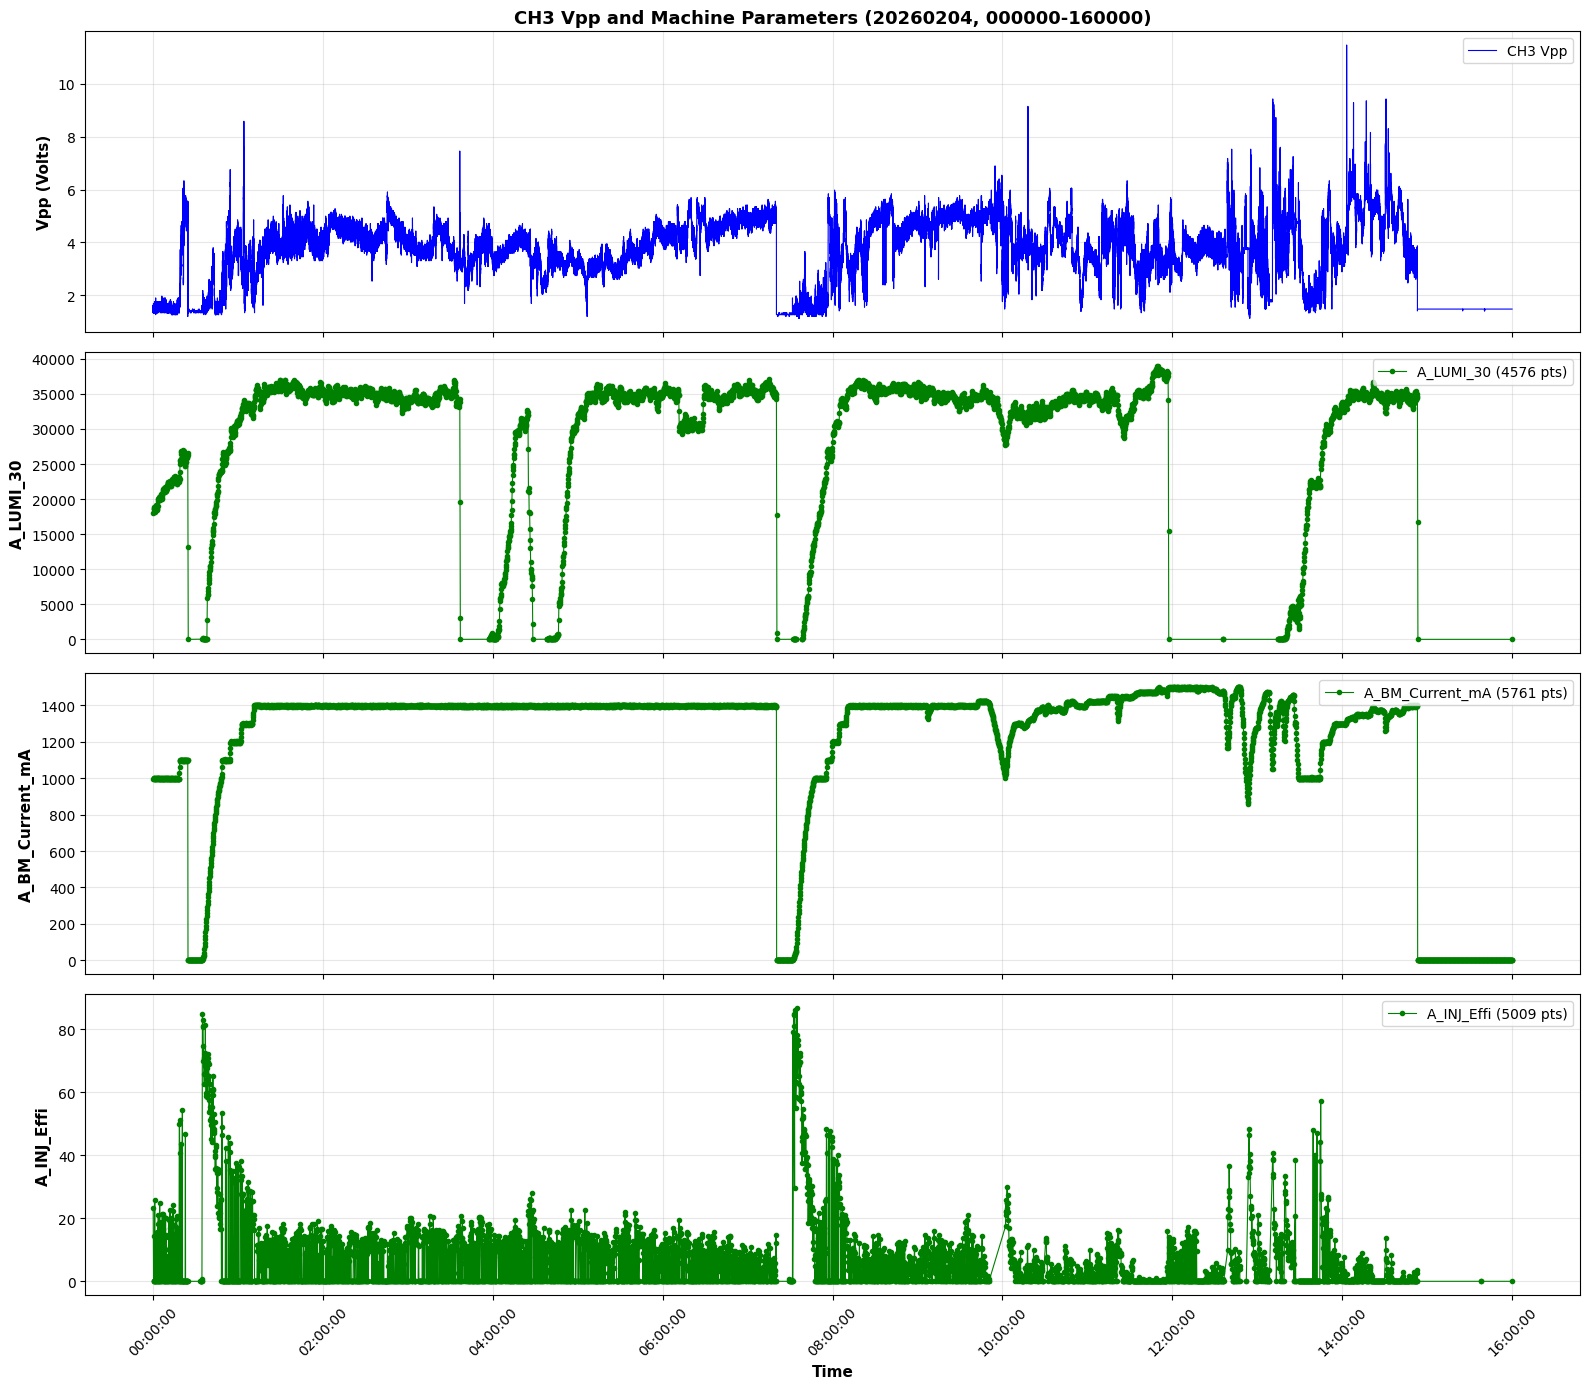


✓ Plotted 3 machine variables with Vpp


In [ ]:
# Multi-panel plot: Vpp + selected machine variables
if filtered_df is not None and len(filtered_df) > 0 and machine_df_filtered is not None and len(machine_df_filtered) > 0:
    
    # Check which variables are available in machine data
    available_vars = []
    missing_vars = []
    
    for var in variables_to_plot:
        if var in machine_df_filtered.columns:
            available_vars.append(var)
        else:
            missing_vars.append(var)
    
    if missing_vars:
        print(f"⚠ Warning: The following variables are not in machine data: {missing_vars}")
    
    if not available_vars:
        print("⚠ None of the selected variables are available in machine data!")
    else:
        # Create figure with subplots (Vpp + available variables)
        num_plots = 1 + len(available_vars)  # 1 for Vpp, rest for machine variables
        fig, axes = plt.subplots(num_plots, 1, figsize=(16, 3.5 * num_plots), sharex=True)
        
        # Handle single plot case
        if num_plots == 1:
            axes = [axes]
        
        # Plot 1: Vpp (acoustic sensor)
        axes[0].plot(filtered_df['time_datetime'], filtered_df['vpp_volts'], 
                    linewidth=0.8, color='blue', label='CH3 Vpp')
        axes[0].set_ylabel("Vpp (Volts)", fontsize=11, fontweight='bold')
        axes[0].set_title(f"CH3 Vpp and Machine Parameters ({date_str}, {start_time_str}-{end_time_str})", 
                         fontsize=13, fontweight='bold')
        axes[0].grid(True, alpha=0.3)
        axes[0].legend(loc='upper right')
        
        # Plot remaining: Machine variables
        for idx, var in enumerate(available_vars):
            ax = axes[idx + 1]
            
            # Filter out NaN values for this variable
            mask_valid = machine_df_filtered[var].notna()
            valid_times = machine_df_filtered.loc[mask_valid, 'time_datetime']
            valid_values = machine_df_filtered.loc[mask_valid, var]
            
            # Count non-null values
            n_valid = len(valid_values)
            
            # Plot machine variable with markers to show sparse data
            if n_valid > 0:
                ax.plot(valid_times, valid_values, 
                       linewidth=0.8, color='green', marker='o', markersize=3, 
                       label=f'{var} ({n_valid} pts)')
            
            ax.set_ylabel(var, fontsize=11, fontweight='bold')
            ax.grid(True, alpha=0.3)
            ax.legend(loc='upper right')
        
        # Format x-axis (only on bottom plot)
        axes[-1].set_xlabel("Time", fontsize=11, fontweight='bold')
        axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
        
        # Set tick label font size for all subplots
        for ax in axes:
            ax.tick_params(axis='both', labelsize=11)
        plt.xticks(rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n✓ Plotted {len(available_vars)} machine variables with Vpp")


elif filtered_df is None or len(filtered_df) == 0:    print("⚠ No machine data to plot")

    print("⚠ No acoustic Vpp data to plot")elif machine_df_filtered is None or len(machine_df_filtered) == 0:

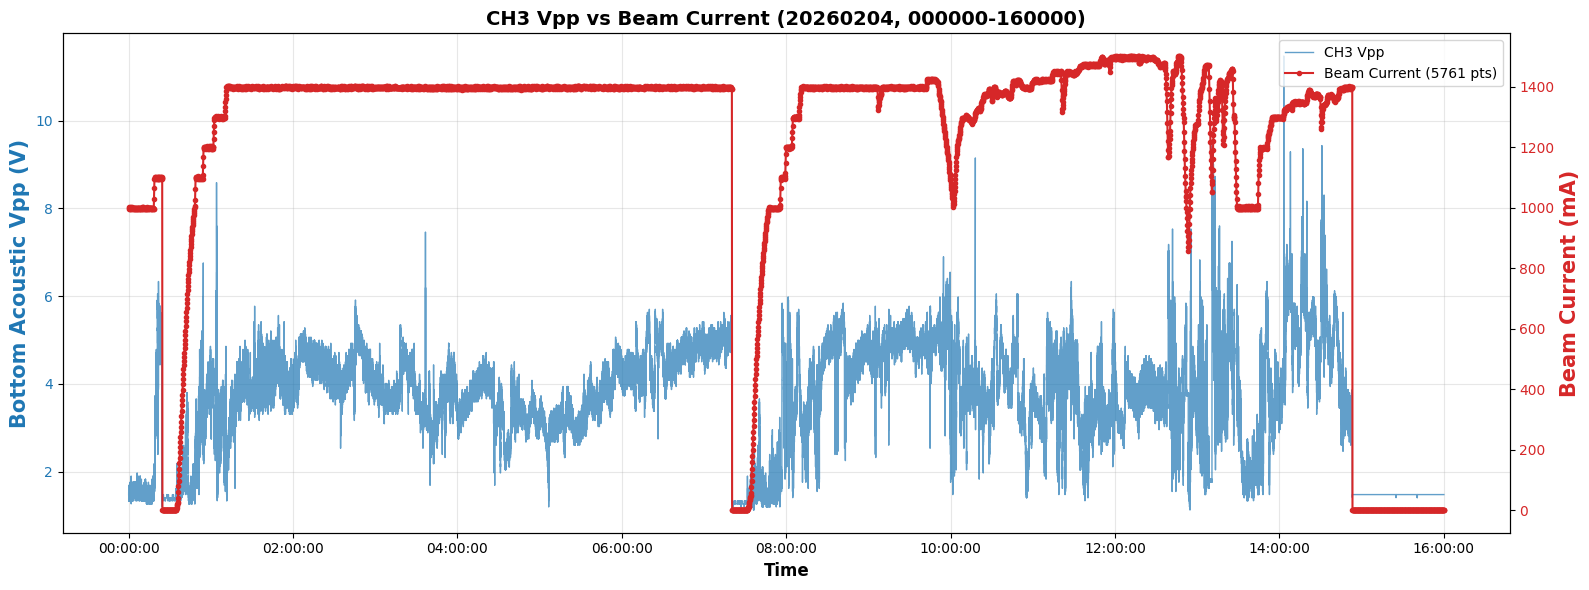

✓ Plotted Vpp with Beam Current
  Vpp samples: 1152332
  Current samples: 5761
  Y-axis limits based on data up to: 160000


In [ ]:
# Dual-axis plot: Vpp and Beam Current on same figure
if filtered_df is not None and len(filtered_df) > 0 and machine_df_filtered is not None and len(machine_df_filtered) > 0:
    
    # Check if beam current is available
    if 'A_BM_Current_mA' in machine_df_filtered.columns:
        # Filter out NaN values for beam current
        mask_valid = machine_df_filtered['A_BM_Current_mA'].notna()
        valid_times = machine_df_filtered.loc[mask_valid, 'time_datetime']
        valid_current = machine_df_filtered.loc[mask_valid, 'A_BM_Current_mA']
        
        # Create figure with dual y-axes
        fig, ax1 = plt.subplots(figsize=(16, 6))
        
        # Plot Vpp on left y-axis (ALL data)
        color_vpp = 'tab:blue'
        ax1.set_xlabel('Time', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Bottom Acoustic Vpp (V)', color=color_vpp, fontsize=15, fontweight='bold')
        line1 = ax1.plot(filtered_df['time_datetime'], filtered_df['vpp_volts'], 
                        linewidth=1, color=color_vpp, alpha=0.7, label='CH3 Vpp')
        ax1.tick_params(axis='y', labelcolor=color_vpp)
        ax1.grid(True, alpha=0.3)
        
        # Plot Beam Current on right y-axis (ALL data)
        ax2 = ax1.twinx()
        color_current = 'tab:red'
        ax2.set_ylabel('Beam Current (mA)', color=color_current, fontsize=15, fontweight='bold')
        line2 = ax2.plot(valid_times, valid_current, 
                        linewidth=1.5, color=color_current, marker='o', markersize=3,
                        label=f'Beam Current ({len(valid_current)} pts)')
        ax2.tick_params(axis='y', labelcolor=color_current)
        
        # Calculate y-axis limits based on masked data (if mask provided)
        if end_time_mask_obj is not None:
            # Get data within mask for y-limit calculation
            mask_vpp = filtered_df['time_datetime'] <= end_time_mask_obj
            vpp_for_ylim = filtered_df.loc[mask_vpp, 'vpp_volts']
            
            mask_current = valid_times <= end_time_mask_obj
            current_for_ylim = valid_current[mask_current]
            
            # Set y-axis limits based on masked data
            if len(vpp_for_ylim) > 0:
                vpp_min, vpp_max = vpp_for_ylim.min(), vpp_for_ylim.max()
                vpp_range = vpp_max - vpp_min
                ax1.set_ylim(vpp_min - 0.05 * vpp_range, vpp_max + 0.05 * vpp_range)
            
            if len(current_for_ylim) > 0:
                current_min, current_max = current_for_ylim.min(), current_for_ylim.max()
                current_range = current_max - current_min
                ax2.set_ylim(current_min - 0.05 * current_range, current_max + 0.05 * current_range)
        
        # Add title
        ax1.set_title(f'CH3 Vpp vs Beam Current ({date_str}, {start_time}-{end_time})', 
                     fontsize=14, fontweight='bold')
        
        # Combined legend
        lines = line1 + line2
        labels = [l.get_label() for l in lines]
        ax1.legend(lines, labels, loc='upper right')
        
        # Format x-axis
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
        ax1.tick_params(axis='both', labelsize=12)
        ax2.tick_params(axis='y', labelsize=12)
        plt.xticks(rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        print(f"✓ Plotted Vpp with Beam Current")
        print(f"  Vpp samples: {len(filtered_df)}")
        print(f"  Current samples: {len(valid_current)}")
        if end_time_mask_obj:
            print(f"  Y-axis limits based on data up to: {end_time}")
    else:
        print("⚠ Beam current (A_BM_Current_mA) not available in machine data")
else:
    if filtered_df is None or len(filtered_df) == 0:
        print("⚠ No acoustic Vpp data available")

    if machine_df_filtered is None or len(machine_df_filtered) == 0:        print("⚠ No machine data available")

In [111]:
# List all available machine variables (for reference)
if machine_df_filtered is not None and len(machine_df_filtered) > 0:
    print("="*60)
    print("Available Machine Variables (Friendly Names)")
    print("="*60)
    
    # Get all numeric columns except time_datetime
    machine_vars = [col for col in machine_df_filtered.columns if col != 'time_datetime']
    
    # Group by prefix
    beam_vars = [v for v in machine_vars if v.startswith('A_')]
    belle2_vars = [v for v in machine_vars if v.startswith('B_')]
    vacuum_vars = [v for v in machine_vars if v.startswith('VAC_')]
    acoustic_vars = [v for v in machine_vars if v.startswith('ACOU_')]
    other_vars = [v for v in machine_vars if not any(v.startswith(p) for p in ['A_', 'B_', 'VAC_', 'ACOU_'])]
    
    if beam_vars:
        print(f"\nBeam/Injection Parameters ({len(beam_vars)}):")
        for v in sorted(beam_vars):
            print(f"  - {v}")
    
    if belle2_vars:
        print(f"\nBelle2 Detector ({len(belle2_vars)}):")
        for v in sorted(belle2_vars):
            print(f"  - {v}")
    
    if vacuum_vars:
        print(f"\nVacuum Sensors ({len(vacuum_vars)}):")
        for v in sorted(vacuum_vars[:10]):  # Show first 10
            print(f"  - {v}")
        if len(vacuum_vars) > 10:
            print(f"  ... and {len(vacuum_vars) - 10} more")
    
    if acoustic_vars:
        print(f"\nAcoustic Sensors ({len(acoustic_vars)}):")
        for v in sorted(acoustic_vars):
            print(f"  - {v}")
    
    if other_vars:
        print(f"\nOther Variables ({len(other_vars)}):")
        for v in sorted(other_vars):
            print(f"  - {v}")
    
    print(f"\nTotal: {len(machine_vars)} variables available")
else:
    print("No machine data available")

Available Machine Variables (Friendly Names)

Beam/Injection Parameters (20):
  - A_BM_BetaX_IP_m
  - A_BM_BetaY_IP_m
  - A_BM_CapSigmaY_um
  - A_BM_Current_mA
  - A_INJ_AngY_rad
  - A_INJ_D7_BPMX_mm
  - A_INJ_D7_BPMY_mm
  - A_INJ_D7_Charge
  - A_INJ_Effi
  - A_INJ_Kicker_Height_mm
  - A_INJ_Kicker_Jump
  - A_INJ_Phase
  - A_INJ_PosY_m
  - A_INJ_Rep_ep_Hz
  - A_INJ_Septum_Ang_mm
  - A_INJ_Septum_Pos_mm
  - A_LUMI_30
  - A_LUMI_SP_30
  - A_Qep_BT_end_nC
  - A_Qep_Linac_end_nC

Total: 20 variables available
